# Phase 3 - Steering Response Experiment

> Project Chrono / Vehicle / Wheeled  
> 목표: HMMWV 차량에서 steering input 변화에 따른 궤적, 속도, yaw 응답 비교

이번 실험은 사람이 직접 조작하지 않고, 고정된 steering input을 case별로 넣어 차량 반응을 비교한다.

```text
Case 1: steering = 0.0
Case 2: steering = 0.2
Case 3: steering = 0.5
```

핵심 분석:

```text
steering input 증가
→ wheel steer angle 증가
→ tire slip angle 증가
→ lateral tire force 증가
→ yaw motion 증가
→ turning radius 감소
```


## 1. Import

In [2]:
import os
import math as m
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import pychrono as chrono
import pychrono.vehicle as veh

print("Chrono import success")
print("NumPy version:", np.__version__)


Chrono import success
NumPy version: 1.26.4


## 2. Path Setting

In [3]:
def find_project_root(start=None):
    if start is None:
        start = Path.cwd()
    start = Path(start).resolve()

    for p in [start] + list(start.parents):
        if (p / ".git").exists() or (p / "docs").exists():
            return p

    return start


PROJECT_ROOT = find_project_root()
RESULT_DIR = PROJECT_ROOT / "results" / "phase3" / "steering_response"
FIGURE_DIR = RESULT_DIR / "figures"

RESULT_DIR.mkdir(parents=True, exist_ok=True)
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

print("PROJECT_ROOT:", PROJECT_ROOT)
print("RESULT_DIR:", RESULT_DIR)
print("FIGURE_DIR:", FIGURE_DIR)


PROJECT_ROOT: C:\Users\lahee\Downloads
RESULT_DIR: C:\Users\lahee\Downloads\results\phase3\steering_response
FIGURE_DIR: C:\Users\lahee\Downloads\results\phase3\steering_response\figures


## 3. Simulation Parameters

In [4]:
# Chrono Vehicle Y-up world frame
veh.ChWorldFrame.SetYUP()

# Contact / tire / powertrain settings
contact_method = chrono.ChContactMethod_NSC
tire_model = veh.TireModelType_TMEASY

# Simulation setting
step_size = 3e-3
tire_step_size = 1e-3
t_end = 12.0

# Terrain
terrain_friction = 0.9

# Fixed driver input
fixed_throttle = 0.4
fixed_braking = 0.0

# Steering cases
steering_cases = [
    {"case_name": "steering_0_0", "steering": 0.0},
    {"case_name": "steering_0_2", "steering": 0.2},
    {"case_name": "steering_0_5", "steering": 0.5},
]

print("Simulation parameters ready")


Simulation parameters ready


## 4. Helper Functions

In [5]:
def get_chassis_body(hmmwv):
    vehicle = hmmwv.GetVehicle()

    if hasattr(vehicle, "GetChassisBody"):
        return vehicle.GetChassisBody()

    if hasattr(vehicle, "GetChassis"):
        chassis = vehicle.GetChassis()
        if hasattr(chassis, "GetBody"):
            return chassis.GetBody()

    raise RuntimeError("Could not access chassis body. Check PyChrono vehicle API.")


def safe_get_rpy_from_body(body):
    rot = body.GetRot()

    try:
        angles = rot.GetCardanAnglesXYZ()
        return float(angles.x), float(angles.y), float(angles.z)
    except Exception:
        return np.nan, np.nan, np.nan


def get_vehicle_speed(hmmwv, body):
    try:
        return float(hmmwv.GetVehicle().GetSpeed())
    except Exception:
        vel = body.GetPosDt()
        return float((vel.x**2 + vel.y**2 + vel.z**2) ** 0.5)


def log_vehicle_state(hmmwv, driver_inputs, case_name):
    system = hmmwv.GetSystem()
    body = get_chassis_body(hmmwv)

    time = float(system.GetChTime())
    pos = body.GetPos()
    vel = body.GetPosDt()
    roll, pitch, yaw = safe_get_rpy_from_body(body)
    speed = get_vehicle_speed(hmmwv, body)

    return {
        "case_name": case_name,
        "time": time,

        # Y-up coordinate: X forward, Y vertical, Z lateral
        "x": float(pos.x),
        "y": float(pos.y),
        "z": float(pos.z),

        "vx": float(vel.x),
        "vy": float(vel.y),
        "vz": float(vel.z),

        "speed": speed,
        "roll": roll,
        "pitch": pitch,
        "yaw": yaw,

        "steering": float(driver_inputs.m_steering),
        "throttle": float(driver_inputs.m_throttle),
        "braking": float(driver_inputs.m_braking),
    }


def estimate_yaw_rate(df_case):
    df_case = df_case.copy()
    if df_case["yaw"].isna().all():
        df_case["yaw_rate"] = np.nan
        return df_case

    yaw = np.unwrap(df_case["yaw"].to_numpy())
    time = df_case["time"].to_numpy()

    if len(time) >= 2:
        df_case["yaw_rate"] = np.gradient(yaw, time)
    else:
        df_case["yaw_rate"] = np.nan

    return df_case


print("Helper functions ready")


Helper functions ready


## 5. One Case Simulation Function

In [6]:
def run_steering_case(case_name, steering_value, throttle_value=0.4, braking_value=0.0):
    """Run one steering response simulation case and return DataFrame."""

    # Initial vehicle location and orientation
    initLoc = chrono.ChVector3d(0, 1, 10)
    initYaw = 0.0

    # Vehicle
    hmmwv = veh.HMMWV_Reduced()

    hmmwv.SetContactMethod(contact_method)
    hmmwv.SetChassisCollisionType(veh.CollisionType_NONE)
    hmmwv.SetChassisFixed(False)
    hmmwv.SetInitPosition(chrono.ChCoordsysd(initLoc, chrono.QuatFromAngleY(initYaw)))

    hmmwv.SetEngineType(veh.EngineModelType_SIMPLE)
    hmmwv.SetTransmissionType(veh.TransmissionModelType_AUTOMATIC_SIMPLE_MAP)
    hmmwv.SetDriveType(veh.DrivelineTypeWV_AWD)
    hmmwv.SetTireType(tire_model)
    hmmwv.SetTireStepSize(tire_step_size)

    hmmwv.Initialize()
    hmmwv.GetSystem().SetCollisionSystemType(chrono.ChCollisionSystem.Type_BULLET)

    # Terrain
    terrain = veh.RigidTerrain(hmmwv.GetSystem())

    patch_mat = chrono.ChContactMaterialNSC()
    patch_mat.SetFriction(terrain_friction)

    patch = terrain.AddPatch(
        patch_mat,
        chrono.ChCoordsysd(chrono.VNULL, chrono.QuatFromAngleX(-m.pi / 2)),
        200.0,
        100.0
    )

    terrain.Initialize()

    # Driver input
    driver_inputs = veh.DriverInputs()
    driver_inputs.m_steering = steering_value
    driver_inputs.m_throttle = throttle_value
    driver_inputs.m_braking = braking_value

    log_rows = []

    while hmmwv.GetSystem().GetChTime() < t_end:
        time = hmmwv.GetSystem().GetChTime()

        log_rows.append(log_vehicle_state(hmmwv, driver_inputs, case_name))

        terrain.Synchronize(time)
        hmmwv.Synchronize(time, driver_inputs, terrain)

        terrain.Advance(step_size)
        hmmwv.Advance(step_size)

    df_case = pd.DataFrame(log_rows)
    df_case = estimate_yaw_rate(df_case)

    return df_case


print("run_steering_case() ready")


run_steering_case() ready


## 6. Run Steering Cases

In [7]:
all_dfs = []

for case in steering_cases:
    print("Running:", case["case_name"], "steering =", case["steering"])

    df_case = run_steering_case(
        case_name=case["case_name"],
        steering_value=case["steering"],
        throttle_value=fixed_throttle,
        braking_value=fixed_braking,
    )

    case_csv_path = RESULT_DIR / f'{case["case_name"]}.csv'
    df_case.to_csv(case_csv_path, index=False, encoding="utf-8-sig")
    print("Saved:", case_csv_path)

    all_dfs.append(df_case)

df = pd.concat(all_dfs, ignore_index=True)

all_csv_path = RESULT_DIR / "steering_response_all_cases.csv"
df.to_csv(all_csv_path, index=False, encoding="utf-8-sig")

print("All cases finished")
print("Saved combined CSV:", all_csv_path)
display(df.head())
display(df.tail())


Running: steering_0_0 steering = 0.0
Saved: C:\Users\lahee\Downloads\results\phase3\steering_response\steering_0_0.csv
Running: steering_0_2 steering = 0.2
Saved: C:\Users\lahee\Downloads\results\phase3\steering_response\steering_0_2.csv
Running: steering_0_5 steering = 0.5
Saved: C:\Users\lahee\Downloads\results\phase3\steering_response\steering_0_5.csv
All cases finished
Saved combined CSV: C:\Users\lahee\Downloads\results\phase3\steering_response\steering_response_all_cases.csv


,case_name,time,x,y,z,vx,vy,vz,speed,roll,pitch,yaw,steering,throttle,braking,yaw_rate
0,steering_0_0,0.000,0.056000,1.213000,10.0,0.000000,0.000000,0.000000e+00,0.000000,-1.570796,0.000000e+00,0.000000,0.0,0.4,0.0,-0.028312
1,steering_0_0,0.003,0.056006,1.212908,10.0,0.001975,-0.030634,-6.863038e-07,-0.004053,-1.570797,-7.627943e-10,-0.000085,0.0,0.4,0.0,-0.029179
2,steering_0_0,0.006,0.056013,1.212716,10.0,0.002207,-0.063879,-2.397985e-06,-0.004182,-1.570797,-1.722348e-09,-0.000175,0.0,0.4,0.0,-0.029090
3,steering_0_0,0.009,0.056019,1.212433,10.0,0.002153,-0.094368,-1.010458e-05,-0.003815,-1.570800,-1.003126e-08,-0.000259,0.0,0.4,0.0,-0.027140
4,steering_0_0,0.012,0.056025,1.212061,10.0,0.002069,-0.124009,-3.576578e-05,-0.003458,-1.570806,-2.787842e-08,-0.000338,0.0,0.4,0.0,-0.025101


,case_name,time,x,y,z,vx,vy,vz,speed,roll,pitch,yaw,steering,throttle,braking,yaw_rate
11995,steering_0_5,11.985,-22.605897,0.633999,-6.486703,1.176324,0.000113,10.667607,10.727539,-1.405113,-1.443458,-0.155590,0.5,0.4,0.0,0.641156
11996,steering_0_5,11.988,-22.602317,0.633999,-6.454704,1.193186,0.000113,10.666186,10.727985,-1.407028,-1.441888,-0.153690,0.5,0.4,0.0,0.625598
11997,steering_0_5,11.991,-22.598687,0.634000,-6.422710,1.210046,0.000113,10.664737,10.728430,-1.408896,-1.440318,-0.151836,0.5,0.4,0.0,0.610594
11998,steering_0_5,11.994,-22.595006,0.634000,-6.390720,1.226905,0.000113,10.663263,10.728877,-1.410721,-1.438747,-0.150026,0.5,0.4,0.0,0.596129
11999,steering_0_5,11.997,-22.591275,0.634000,-6.358735,1.243762,0.000113,10.661760,10.729322,-1.412503,-1.437175,-0.148259,0.5,0.4,0.0,0.589022


## 7. X-Z Trajectory Comparison

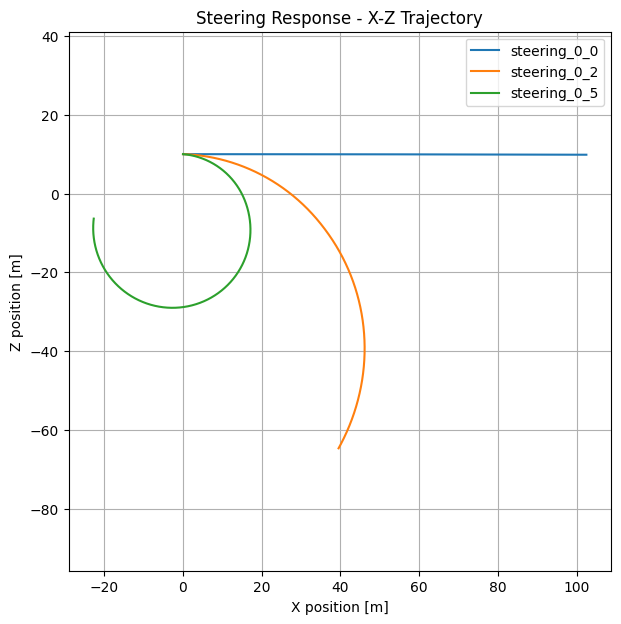

Saved figure: C:\Users\lahee\Downloads\results\phase3\steering_response\figures\steering_response_trajectory.png


In [8]:
plt.figure(figsize=(7, 7))

for case_name, df_case in df.groupby("case_name"):
    plt.plot(df_case["x"], df_case["z"], label=case_name)

plt.xlabel("X position [m]")
plt.ylabel("Z position [m]")
plt.title("Steering Response - X-Z Trajectory")
plt.axis("equal")
plt.grid(True)
plt.legend()

fig_path = FIGURE_DIR / "steering_response_trajectory.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


## 8. Speed Response

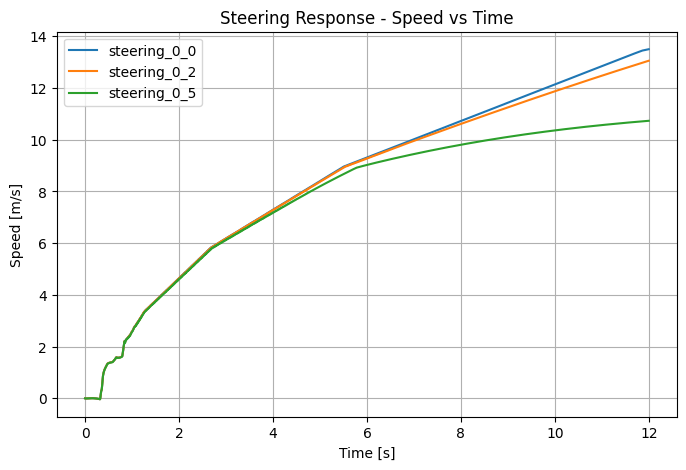

Saved figure: C:\Users\lahee\Downloads\results\phase3\steering_response\figures\steering_response_speed.png


In [9]:
plt.figure(figsize=(8, 5))

for case_name, df_case in df.groupby("case_name"):
    plt.plot(df_case["time"], df_case["speed"], label=case_name)

plt.xlabel("Time [s]")
plt.ylabel("Speed [m/s]")
plt.title("Steering Response - Speed vs Time")
plt.grid(True)
plt.legend()

fig_path = FIGURE_DIR / "steering_response_speed.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


## 9. Yaw Response

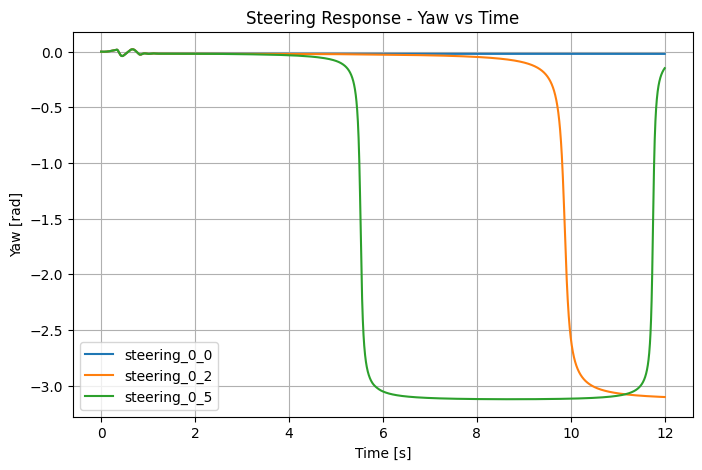

Saved figure: C:\Users\lahee\Downloads\results\phase3\steering_response\figures\steering_response_yaw.png


In [10]:
plt.figure(figsize=(8, 5))

for case_name, df_case in df.groupby("case_name"):
    plt.plot(df_case["time"], df_case["yaw"], label=case_name)

plt.xlabel("Time [s]")
plt.ylabel("Yaw [rad]")
plt.title("Steering Response - Yaw vs Time")
plt.grid(True)
plt.legend()

fig_path = FIGURE_DIR / "steering_response_yaw.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


## 10. Yaw Rate Response

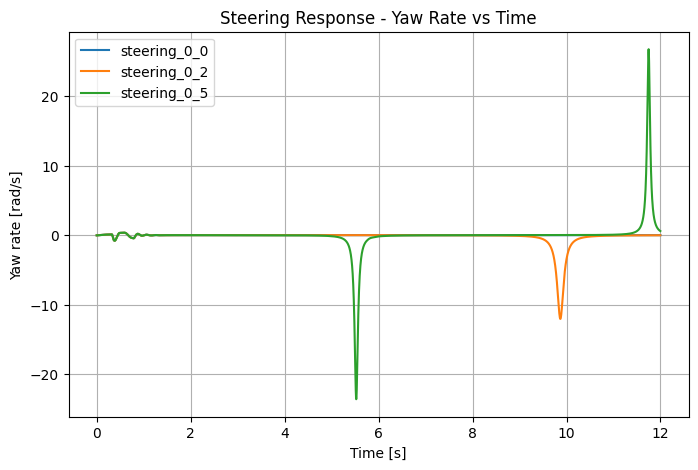

Saved figure: C:\Users\lahee\Downloads\results\phase3\steering_response\figures\steering_response_yaw_rate.png


In [11]:
plt.figure(figsize=(8, 5))

for case_name, df_case in df.groupby("case_name"):
    plt.plot(df_case["time"], df_case["yaw_rate"], label=case_name)

plt.xlabel("Time [s]")
plt.ylabel("Yaw rate [rad/s]")
plt.title("Steering Response - Yaw Rate vs Time")
plt.grid(True)
plt.legend()

fig_path = FIGURE_DIR / "steering_response_yaw_rate.png"
plt.savefig(fig_path, dpi=200, bbox_inches="tight")
plt.show()

print("Saved figure:", fig_path)


## 11. Summary Metrics

In [12]:
summary_rows = []

for case_name, df_case in df.groupby("case_name"):
    travel_x = df_case["x"].iloc[-1] - df_case["x"].iloc[0]
    lateral_z = df_case["z"].iloc[-1] - df_case["z"].iloc[0]
    final_yaw = df_case["yaw"].iloc[-1]
    mean_speed = df_case["speed"].mean()
    max_speed = df_case["speed"].max()
    mean_abs_yaw_rate = df_case["yaw_rate"].abs().mean()

    # simple curvature-like indicator
    # larger |lateral_z / travel_x| means stronger turning
    if abs(travel_x) > 1e-6:
        lateral_ratio = lateral_z / travel_x
    else:
        lateral_ratio = np.nan

    summary_rows.append({
        "case_name": case_name,
        "steering": df_case["steering"].iloc[0],
        "travel_x_m": travel_x,
        "lateral_z_m": lateral_z,
        "lateral_ratio_z_over_x": lateral_ratio,
        "final_yaw_rad": final_yaw,
        "mean_speed_mps": mean_speed,
        "max_speed_mps": max_speed,
        "mean_abs_yaw_rate_radps": mean_abs_yaw_rate,
    })

summary_df = pd.DataFrame(summary_rows)

summary_path = RESULT_DIR / "steering_response_summary.csv"
summary_df.to_csv(summary_path, index=False, encoding="utf-8-sig")

print("Saved summary:", summary_path)
display(summary_df)


Saved summary: C:\Users\lahee\Downloads\results\phase3\steering_response\steering_response_summary.csv


,case_name,steering,travel_x_m,lateral_z_m,lateral_ratio_z_over_x,final_yaw_rad,mean_speed_mps,max_speed_mps,mean_abs_yaw_rate_radps
0,steering_0_0,0.0,102.359288,-0.143907,-0.001406,-0.019962,8.527193,13.495987,0.018105
1,steering_0_2,0.2,39.479327,-74.643824,-1.890707,-3.102193,8.418523,13.050601,0.274766
2,steering_0_5,0.5,-22.647275,-16.358735,0.722327,-0.148259,7.780847,10.729322,0.524158


## 12. Interpretation Guide

결과 해석은 다음 기준으로 하면 된다.

```text
1. steering = 0.0:
   - 거의 직진해야 한다.
   - z 방향 이동과 yaw 변화가 작아야 한다.

2. steering = 0.2:
   - 완만한 선회가 나타나야 한다.
   - x-z trajectory가 곡선 형태로 변해야 한다.

3. steering = 0.5:
   - 더 강한 선회가 나타나야 한다.
   - yaw rate와 lateral displacement가 커져야 한다.
   - 속도는 선회 저항 때문에 약간 낮아질 수 있다.
```

